You can order print and ebook versions of *Think Bayes 2e* from
[Bookshop.org](https://bookshop.org/a/98697/9781492089469) and
[Amazon](https://amzn.to/334eqGo).

# Counting Diabetes Cases with Mark and Recapture

In epidemiology, the true number of people with a condition is often larger than the number who appear on any official list.
If we have several incomplete lists, and we can match individuals across them, the pattern of overlaps is informative: few repeats suggest many missing cases; many repeats suggest we have seen most of the cases.

The key to this approach is [mark and recapture modeling](https://en.wikipedia.org/wiki/Mark_and_recapture), a method originally developed for ecology, but applicable in many other domains.
In [this excellent paper](https://doi.org/10.1002/9781118445112.stat04855.pub2),
Anne Chao reviews the approach and presents two examples.
Here we use the second: counting people with diabetes in an Italian community, based on data collected by Bruno et al. (1994).

Four incomplete lists of cases were available:

1. Clinic (1754 cases): diabetic clinic and/or family physician visits.
2. Hospital (452 cases): hospital discharges.
3. Rx (1135 cases): prescriptions.
4. Supplies (173 cases): purchases of reagent strips and insulin syringes.

Across the four lists, 2069 distinct people were identified.
Despite active case finding, Bruno et al. concluded that some people with diabetes were still missed.
The question is how many.

Compared with the three-list hepatitis A example in Chao’s paper (and in the companion notebook `hepatitis.ipynb`), this dataset has a high overlapping fraction (sample coverage about 80%).
Chao’s recommended coverage-based estimate is `N̂ ≈ 2609` (95% CI about 2477–2784), versus an independence-based `N̂0 ≈ 2272`.
Pairwise diagnostics also flag strong positive dependence involving the Supplies list (especially with Hospital and Rx).

We'll fit the same two Bayesian models as in the hepatitis notebook — homogeneous detection, then individual heterogeneity — adapted to four lists, and compare the posteriors to Chao’s estimates.

[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/ThinkBayes2/blob/master/examples/diabetes.ipynb).

In [1]:
# install empiricaldist if necessary
try:
    import empiricaldist
except ImportError:
    !pip install empiricaldist

In [2]:
# Get utils.py

from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)
    
download('https://github.com/AllenDowney/ThinkBayes2/raw/master/soln/utils.py')

In [3]:
try:
    import pymc as pm
except ImportError:
    !pip install pymc arviz

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.stats import norm

import pymc as pm
import arviz as az

from utils import decorate, set_pyplot_params

In [5]:
np.random.seed(0)
np.set_printoptions(legacy='1.25')
set_pyplot_params()

## The Data

We can summarize the data by listing the number of cases in each of the $2^4 - 1 = 15$ observable cells (all patterns except never listed).
Following Chao’s Table 2, the four list indicators are Clinic, Hospital, Rx, and Supplies.

```
C  H  R  S   count
1  1  1  1    58
1  1  1  0   157
1  1  0  1    18
1  1  0  0   104
1  0  1  1    46
1  0  1  0   650
1  0  0  1    12
1  0  0  0   709
0  1  1  1    14
0  1  1  0    20
0  1  0  1     7
0  1  0  0    74
0  0  1  1     8
0  0  1  0   182
0  0  0  1    10
0  0  0  0    ??
```

Of course the all-zero cell is unknown. That's what we'll estimate!

For the models below, we store the 15 observed counts in the same order as `itertools.product([0, 1], repeat=4)` excluding `(0,0,0,0)` — that is, binary counting from `0001` through `1111`.

In [6]:
from itertools import product

patterns = np.array(list(product([0, 1], repeat=4)), dtype=float)
patterns

array([[0., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 1.],
       [0., 1., 0., 0.],
       [0., 1., 0., 1.],
       [0., 1., 1., 0.],
       [0., 1., 1., 1.],
       [1., 0., 0., 0.],
       [1., 0., 0., 1.],
       [1., 0., 1., 0.],
       [1., 0., 1., 1.],
       [1., 1., 0., 0.],
       [1., 1., 0., 1.],
       [1., 1., 1., 0.],
       [1., 1., 1., 1.]])

In [7]:
# Cell counts for patterns 0001 … 1111 (k0000 unknown)
observed = np.array(
    [10, 182, 8, 74, 7, 20, 14, 709, 12, 650, 46, 104, 18, 157, 58]
)
num_seen = observed.sum()
num_seen

2069

So 2069 distinct cases appear on at least one list.
Once we estimate `k0000`, we can compute `N = num_seen + k0000`.

## Homogeneous model

We'll start with what I'll call the homogeneous model, because it assumes that every person with diabetes has the same probability of appearing on a given list — but different probabilities for the four lists.

With that assumption, the probability of each of the 16 capture patterns is the product of list probabilities and their complements (see the model below).

For the prior distribution of `k0000` we'll use a Poisson distribution with a weakly informative hyperprior on the Poisson mean.
For the list probabilities, the prior is a Beta distribution with parameters (1, 1), which is uniform from 0 to 1.

Here's the model.

In [8]:
coords = {"list": ["Clinic", "Hospital", "Rx", "Supplies"]}

In [9]:
with pm.Model(coords=coords) as model:
    p = pm.Beta("p", alpha=1, beta=1, dims="list")

    mu = pm.HalfNormal("mu", sigma=500)
    k0000 = pm.Poisson("k0000", mu=mu)
    N = pm.Deterministic("N", num_seen + k0000)

    # Probability of each pattern under list-wise independence given p
    # shape: cell × list
    y = patterns
    cell_probs = pm.math.prod(
        p[None, :] ** y * (1 - p[None, :]) ** (1 - y),
        axis=1,
    )

    counts = pm.math.stack([k0000, *observed])
    pm.Potential(
        "likelihood",
        pm.logp(pm.Multinomial.dist(n=N, p=cell_probs), counts),
    )

As a technical note, you might wonder why we can't write the likelihood like this:

```    
likelihood = pm.Multinomial("likelihood", n=N, p=cell_probs, observed=counts)
```

The problem is that the value we pass as `observed` has to be constant — it can't be a random variable or contain any random variables — and `counts` contains the random variable `k0000`.
Instead we use `Potential` to compute the log likelihood of the data directly.

Here's a graphical representation of the model.

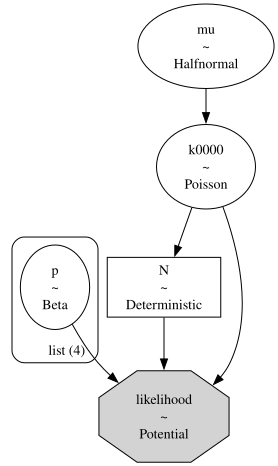

In [10]:
pm.model_to_graphviz(model)

Notice that `k0000` affects the likelihood of the data in two ways: directly as one of the counts and indirectly as a term of `N = num_seen + k0000`.

In [11]:
with model:
    idata = pm.sample(2000, tune=2000, random_seed=42, target_accept=0.9)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [p, mu]
>Metropolis: [k0000]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 6 seconds.


In [12]:
az.summary(idata, var_names=["N", "p", "mu", "k0000"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
N,2251.390,18.341,2218.000,2285.000,0.878,0.468,436.0,766.0,1.0
p[Clinic],0.779,0.011,0.760,0.800,0.000,0.000,1015.0,2227.0,1.0
p[Hospital],0.201,0.009,0.185,0.217,0.000,0.000,6566.0,5505.0,1.0
p[Rx],0.504,0.011,0.483,0.526,0.000,0.000,2405.0,3973.0,1.0
p[Supplies],0.077,0.006,0.067,0.088,0.000,0.000,8420.0,5729.0,1.0
mu,183.470,22.785,140.647,226.672,0.942,0.422,585.0,1293.0,1.0
k0000,182.390,18.341,149.000,216.000,0.878,0.468,436.0,766.0,1.0


The model samples reasonably well. Here are the posterior distributions.

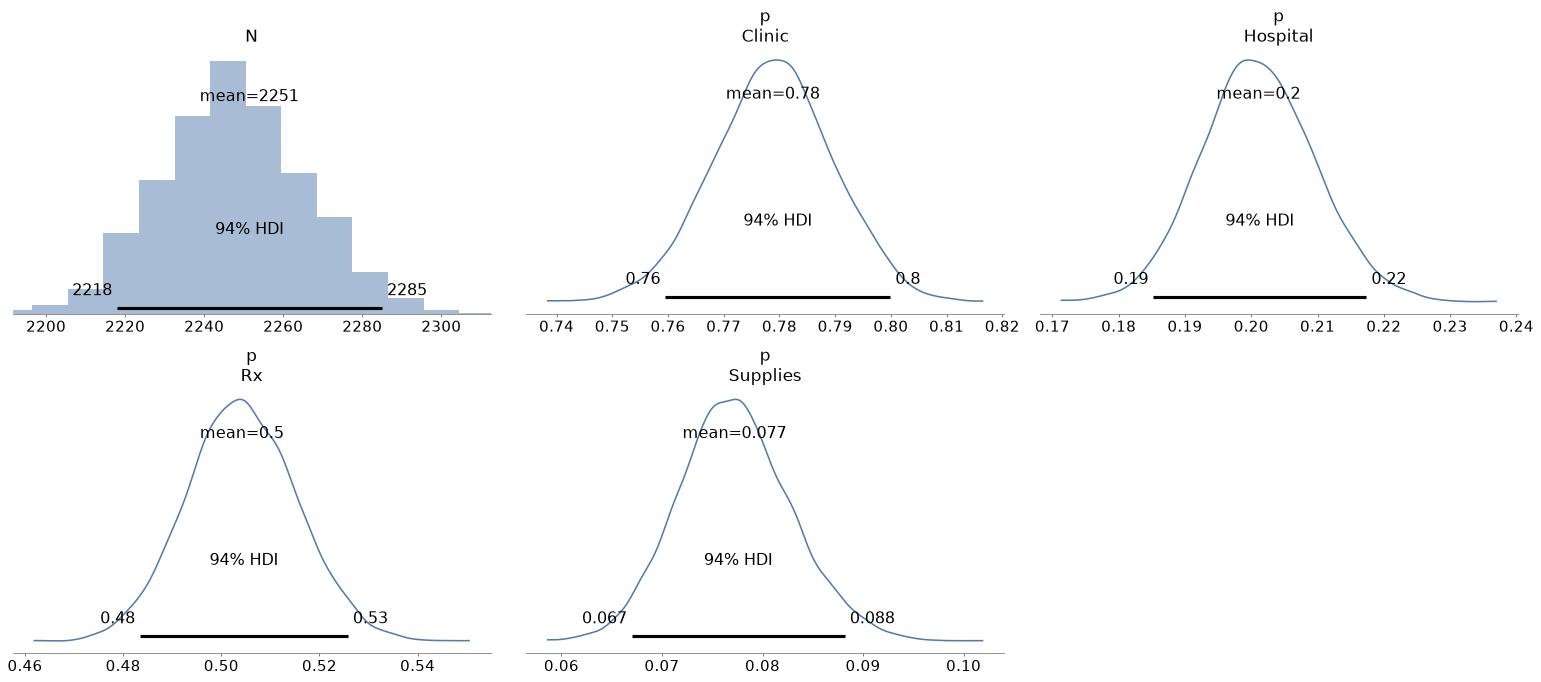

In [13]:
az.plot_posterior(idata, var_names=["N", "p"])
decorate()

And here's the estimated value of `N` with a 90% CI.

In [14]:
az.summary(idata, var_names=["N"], hdi_prob=0.9)

,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
N,2251.39,18.341,2222.0,2281.0,0.878,0.468,436.0,766.0,1.0


The posterior mean is about 2251, with a 90% HDI from about 2222 to 2281 — close to Chao’s independence estimator `N̂0 ≈ 2272`.
That estimate ignores dependence among lists.
Chao’s pairwise Petersen/Chapman numbers already suggest strong positive dependence for some pairs (especially Hospital–Supplies and Rx–Supplies), so the homogeneous model is expected to underestimate `N` relative to the dependence-adjusted coverage estimator `N̂ ≈ 2609`.
And in this example, it does: 2251 is well below 2609.

The homogeneous model treats each person as equally likely to appear on a given list.
It also assumes that, after accounting for the different coverage of the four lists, appearing on one list provides no information about appearing on another.
Both assumptions are questionable.

In reality, some people are easier to detect than others — for example, because they have more contact with clinics, hospitals, or pharmacies.
Such people would be more likely to appear on several lists, while others might appear on none.

If that's true, the data will contain more repeated observations than the homogeneous model expects.
In that case, the homogeneous model interprets the observed overlap as evidence that the lists have covered most of the population, and it tends to underestimate the number of cases.

So let's build a better model.

## Individual heterogeneity

We'll assume that each person has a level of detectability, $z_k$, and each list has a baseline detection level $\alpha_j$.
For a person with detectability $z_k$, the chance they appear on list `j` is `p_{kj}`, where

$$\mathrm{logit}(p_{kj}) = \alpha_j + \sigma z_k$$

Here $\sigma$ controls how much influence individual detectability has, compared to the baseline detection levels.
A person with high $z_k$ is more likely to appear on more than one list; people with low detectability are more likely to be missed entirely.

To implement this model, we don't need a latent variable for every person.
Instead, we'll assume there are 21 detectability levels, `z_k`, and assign each level a weight, `w_k`, that represents the fraction of people in the population at that level.
Then we can compute the cell probabilities using a weighted sum of the cell probabilities conditioned on `z_k`.

$$\pi_{s} = \sum_k w_k \, P(s \mid z_k)$$

We'll precompute the values of `z` and the corresponding weights (using the PDF of a normal distribution to make a bell curve).

In [15]:
z = np.linspace(-4, 4, 21)
weights = norm.pdf(z)
weights /= weights.sum()

The capture patterns were already defined above (`product` over four lists).
Now here's a function that builds the model.
The argument `sigma_prior_scale` is the scale of the half-normal prior on $\sigma$; we'll vary it later to check sensitivity.

In [16]:
def make_heterogeneity_model(sigma_prior_scale=1):
    with pm.Model(coords=coords) as model:
        alpha = pm.Normal("alpha", mu=0, sigma=1.5, dims="list")
        sigma = pm.HalfNormal("sigma", sigma=sigma_prior_scale)

        # Probability someone with z=0 appears on each list
        p_typical = pm.Deterministic(
            "p_typical", pm.math.sigmoid(alpha), dims="list"
        )

        # Probability someone with each level of z appears on each list
        # shape: level × list
        logits = alpha[None, :] + sigma * z[:, None]
        p_z = pm.math.sigmoid(logits)

        # Population average probability of appearing on each list
        p_avg = pm.Deterministic(
            "p_avg",
            pm.math.sum(p_z * weights[:, None], axis=0),
            dims="list",
        )

        # Probability of each cell for each level of z and list
        # shape: cell × level × list
        y = patterns[:, None, :]
        cell_prob_given_z = pm.math.prod(
            p_z[None, :, :] ** y * (1 - p_z[None, :, :]) ** (1 - y),
            axis=2,
        )

        # Mixture over levels of z; shape: cell
        probs = pm.math.sum(cell_prob_given_z * weights[None, :], axis=1)
        probs = probs / pm.math.sum(probs)

        # The rest of this model is the same as the previous one
        mu = pm.HalfNormal("mu", sigma=500)
        k0000 = pm.Poisson("k0000", mu=mu)
        N = pm.Deterministic("N", num_seen + k0000)

        counts = pm.math.stack([k0000, *observed])
        pm.Potential(
            "likelihood",
            pm.logp(pm.Multinomial.dist(n=N, p=probs), counts),
        )
    return model

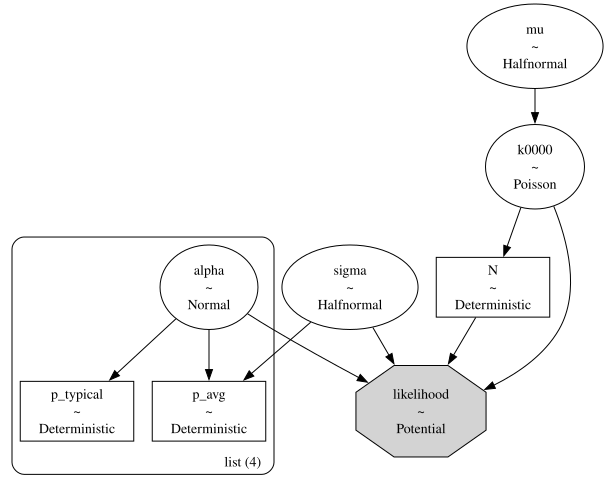

In [17]:
heterogeneity_model = make_heterogeneity_model()
pm.model_to_graphviz(heterogeneity_model)

In [18]:
with heterogeneity_model:
    idata_het = pm.sample(2000, tune=2000, random_seed=42)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [alpha, sigma, mu]
>Metropolis: [k0000]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 13 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


This model doesn't sample as well — `r_hat` for `N` is a bit high and the effective sample size is modest — but the posterior mean is stable enough for our purposes.

In [19]:
az.summary(
    idata_het,
    var_names=["N", "alpha", "sigma", "p_typical", "p_avg", "mu", "k0000"],
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
N,2661.309,83.139,2527.000,2823.000,13.818,3.862,35.0,209.0,1.10
alpha[Clinic],0.847,0.108,0.638,1.036,0.015,0.004,51.0,302.0,1.08
alpha[Hospital],-1.989,0.115,-2.213,-1.784,0.016,0.004,54.0,418.0,1.07
alpha[Rx],-0.378,0.094,-0.551,-0.203,0.014,0.003,47.0,387.0,1.08
alpha[Supplies],-3.230,0.142,-3.502,-2.978,0.019,0.003,56.0,623.0,1.06
sigma,1.199,0.096,1.020,1.375,0.014,0.003,49.0,306.0,1.07
p_typical[Clinic],0.699,0.023,0.658,0.741,0.003,0.001,51.0,302.0,1.08
p_typical[Hospital],0.121,0.012,0.098,0.143,0.002,0.000,54.0,418.0,1.07
p_typical[Rx],0.407,0.023,0.366,0.449,0.003,0.001,47.0,387.0,1.08
p_typical[Supplies],0.038,0.005,0.029,0.048,0.001,0.000,56.0,623.0,1.06


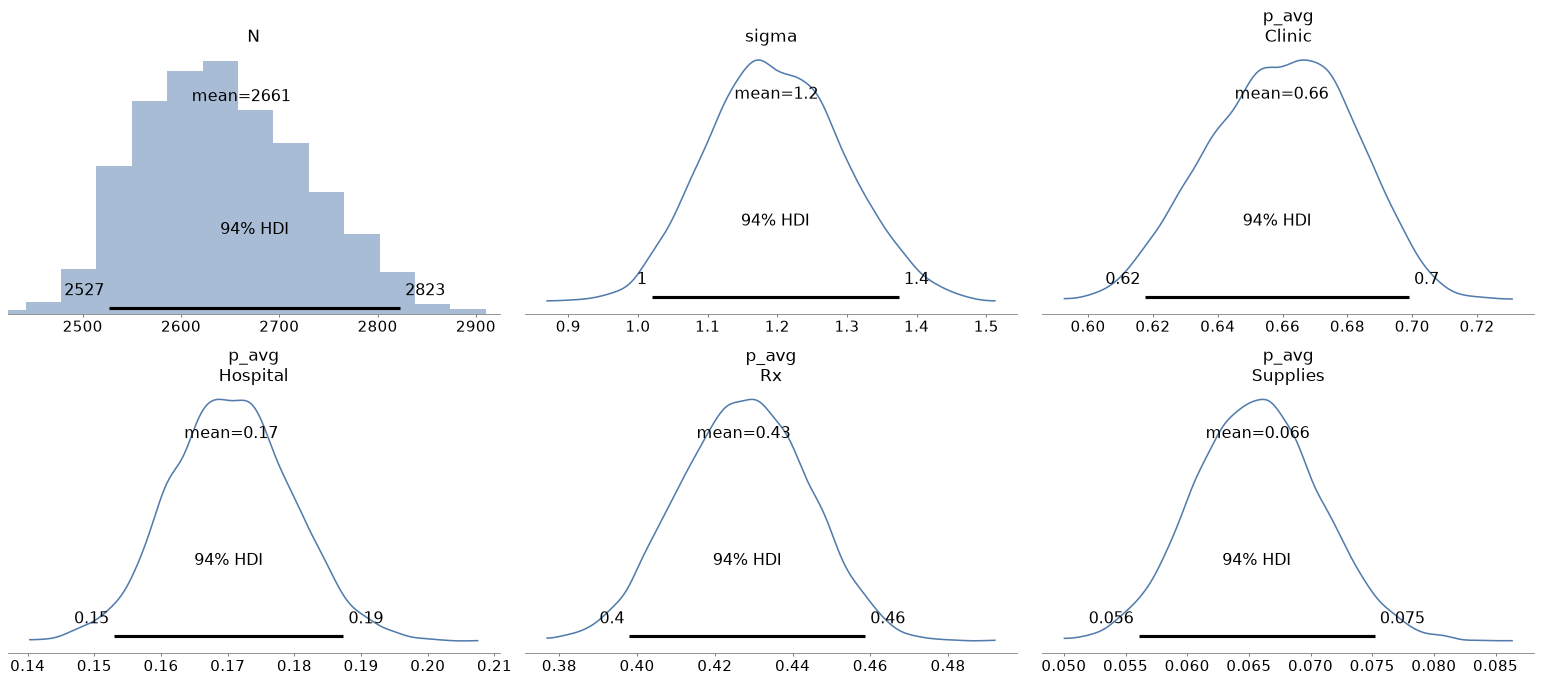

In [20]:
az.plot_posterior(idata_het, var_names=["N", "sigma", "p_avg"])
decorate()

In [21]:
az.summary(idata_het, var_names=["N"], hdi_prob=0.9)

,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
N,2661.309,83.139,2528.0,2793.0,13.818,3.862,35.0,209.0,1.1


Unlike the hepatitis outbreak, there is no campus-wide screen that gives a known true `N`.
Instead we compare to Chao’s sample-coverage estimates: independence `N̂0 ≈ 2272` and recommended `N̂ ≈ 2609` (95% CI about 2477–2784).

The heterogeneity posterior mean is about 2661, with a 90% HDI from about 2528 to 2793.
That is much closer to Chao’s `N̂` than the homogeneous model was, and the interval overlaps Chao’s reported confidence interval.
As in the hepatitis example, allowing individual variation in detectability pulls `N` upward once the lists share more repeats than a homogeneous model can explain.

Here are the posterior distributions of the two models (dashed lines mark Chao’s `N̂0` and `N̂`).

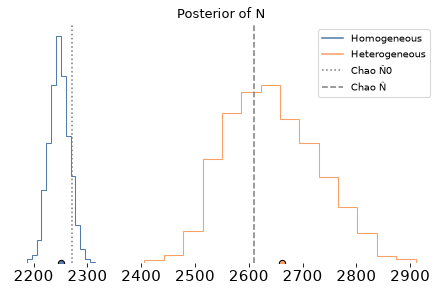

In [22]:
az.plot_density(
    [idata, idata_het],
    var_names=["N"],
    data_labels=["Homogeneous", "Heterogeneous"],
)
plt.axvline(2272, ls=":", color="gray", label="Chao N̂0")
plt.axvline(2609, ls="--", color="gray", label="Chao N̂")
decorate(title="Posterior of N")

In [23]:
summary_ind = az.summary(idata, var_names=["N"], hdi_prob=0.9)
summary_het = az.summary(idata_het, var_names=["N"], hdi_prob=0.9)
pd.DataFrame(
    {
        "mean": [summary_ind.loc["N", "mean"], summary_het.loc["N", "mean"]],
        "hdi_5%": [summary_ind.loc["N", "hdi_5%"], summary_het.loc["N", "hdi_5%"]],
        "hdi_95%": [summary_ind.loc["N", "hdi_95%"], summary_het.loc["N", "hdi_95%"]],
    },
    index=["Homogeneous", "Heterogeneous"],
)

,mean,hdi_5%,hdi_95%
Homogeneous,2251.390,2222.0,2281.0
Heterogeneous,2661.309,2528.0,2793.0


## Sensitivity to Priors

With fifteen observed cells the baselines $\alpha_j$ and $\sigma$ can still trade off.
Larger $\sigma$ creates a subgroup with low probability of detection, which can support a larger unseen population.
So the upper tail of `N` may be prior-sensitive.

To check, we'll test a few values of `sigma_prior_scale`, which controls the width of the prior distribution of $\sigma$.

In [24]:
def fit_heterogeneity(sigma_prior_scale, random_seed=42):
    model = make_heterogeneity_model(sigma_prior_scale)
    with model:
        idata_s = pm.sample(
            1000, tune=1000, random_seed=random_seed, progressbar=False
        )
    return idata_s

In [25]:
sensitivity = []
for scale in [0.5, 1.0, 2.0]:
    idata_s = fit_heterogeneity(scale)
    s = az.summary(idata_s, var_names=["N", "sigma"], hdi_prob=0.9)
    sensitivity.append(
        {
            "HalfNormal scale": scale,
            "N mean": s.loc["N", "mean"],
            "N 5%": s.loc["N", "hdi_5%"],
            "N 95%": s.loc["N", "hdi_95%"],
            "sigma mean": s.loc["sigma", "mean"],
        }
    )

pd.DataFrame(sensitivity).round(1)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [alpha, sigma, mu]
>Metropolis: [k0000]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [alpha, sigma, mu]
>Metropolis: [k0000]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is

,HalfNormal scale,N mean,N 5%,N 95%,sigma mean
0,0.5,2644.5,2506.0,2759.0,1.2
1,1.0,2683.3,2545.0,2832.0,1.2
2,2.0,2676.6,2517.0,2809.0,1.2


Across these scales, the posterior mean of `N` stays in a narrow range (about 2645–2683), and the mean of `sigma` is about 1.2 in each case.
So for this dataset, once the prior on `sigma` is wide enough to allow meaningful heterogeneity, the results are not very sensitive to the exact scale.

Copyright 2026 Allen B. Downey

License: [Attribution-NonCommercial-ShareAlike 4.0 International (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/)